# 08 - Filling Missing Values with Scikit-Learn

Same goal as `07_Filling_Missing_Values.ipynb` - fill the gaps in `loans.csv` - but this time using scikit-learn's `SimpleImputer` instead of pandas' `.fillna()`. Same underlying ideas (mean/median/mode), different tool - and `SimpleImputer` is the one you'll actually reach for once real models get built in `phase_3_classical_ml/`, since it plugs directly into scikit-learn pipelines.

What this notebook covers, in order: loading and auditing the data, meeting `SimpleImputer`, filling `LoanAmount` and friends with `strategy="mean"`, a real before/after picture of what that actually did to the data, a cautionary example of where mean is the *wrong* choice, and a full side-by-side comparison of every `SimpleImputer` strategy.

Start with the usual trio below.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

Load `loans.csv` - the same dataset every notebook in this folder has used since `05_Data_Cleaning_Practice.ipynb` - and preview the first 3 rows.

In [2]:
dataset = pd.read_csv("loans.csv")
dataset.head(3)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001001,Male,Yes,0,Not Graduate,No,1686.0,1020,80.0,360.0,1.0,Semiurban,Y
1,LP001002,Male,Yes,0,Not Graduate,No,2437.0,1201,122.0,360.0,1.0,Urban,Y
2,LP001003,Female,No,0,Graduate,No,8313.0,1065,319.0,360.0,1.0,Urban,Y


Missing-value audit - same first move as every cleaning notebook so far: which columns actually need filling.

In [3]:
dataset.isnull().sum()

Loan_ID               0
Gender               13
Married               6
Dependents           15
Education             9
Self_Employed        32
ApplicantIncome       2
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     21
Credit_History       50
Property_Area         9
Loan_Status           0
dtype: int64

A second view of the same gaps via `.info()` - its **Dtype** column matters here specifically, because `SimpleImputer`'s numeric strategies (`mean`/`median`) only make sense for numeric columns.

In [4]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 618 entries, 0 to 617
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            618 non-null    str    
 1   Gender             605 non-null    str    
 2   Married            612 non-null    str    
 3   Dependents         603 non-null    str    
 4   Education          609 non-null    str    
 5   Self_Employed      586 non-null    str    
 6   ApplicantIncome    616 non-null    float64
 7   CoapplicantIncome  618 non-null    int64  
 8   LoanAmount         596 non-null    float64
 9   Loan_Amount_Term   597 non-null    float64
 10  Credit_History     568 non-null    float64
 11  Property_Area      609 non-null    str    
 12  Loan_Status        618 non-null    str    
dtypes: float64(4), int64(1), str(8)
memory usage: 62.9 KB


Which columns are actually `float64`? These are the ones about to get filled with `strategy="mean"`.

**Worth knowing:** this only grabs `float64` - `CoapplicantIncome` is `int64` and would slip straight through this filter even if it had missing values (it doesn't here, so it's harmless in this specific run, but it's a narrow net in general). `dataset.select_dtypes(include=["int64", "float64"])` is the safer, more complete version - same pattern as the `numerical_cols` line in `07_Filling_Missing_Values.ipynb`.

In [5]:
dataset.select_dtypes(include="float64").columns

Index(['ApplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History'], dtype='str')

## Meet `SimpleImputer`

Scikit-learn's dedicated imputation tool - the `scikit-learn` entry from `02_ML_Roadmap.MD`'s toolbox table, put to use for real for the first time in this repo.

In [6]:
from sklearn.impute import SimpleImputer

`SimpleImputer(strategy="mean")` configures *what* to fill with, but doesn't touch any data yet. `.fit_transform(...)` does two jobs in one call: **`fit`** learns each of the 4 selected columns' own mean from the data, **`transform`** immediately applies it, filling every gap.

One thing to know before the next cell: the result, `ar`, is a plain NumPy array - scikit-learn strips the column names and index off, which is exactly why the next step has to manually put them back.

In [7]:
si = SimpleImputer(strategy="mean")
ar = si.fit_transform(dataset[['ApplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History']])

Rebuilding a proper DataFrame from the bare array - same column order used to select them originally, so the names line back up correctly.

In [8]:
new_dataset = pd.DataFrame(ar,columns=dataset.select_dtypes(include="float64").columns)

The filled result. Every `LoanAmount` / `Loan_Amount_Term` / `Credit_History` / `ApplicantIncome` cell that was `NaN` now holds that column's mean.

In [9]:
new_dataset

,ApplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
0,1686.0,80.0,360.0,1.0
1,2437.0,122.0,360.0,1.0
2,8313.0,319.0,360.0,1.0
3,5069.0,218.0,360.0,1.0
4,3002.0,194.0,360.0,0.0
...,...,...,...,...
613,3153.0,114.0,360.0,0.0
614,3995.0,215.0,360.0,1.0
615,3916.0,250.0,360.0,0.0
616,2366.0,101.0,360.0,1.0


Verify: every column here should read `0` now.

In [10]:
new_dataset.isnull().sum()

ApplicantIncome     0
LoanAmount          0
Loan_Amount_Term    0
Credit_History      0
dtype: int64

Sanity check - does `new_dataset`'s filled `LoanAmount` actually match this original mean? If `SimpleImputer` worked correctly, every previously-missing `LoanAmount` cell should now hold exactly this number.

In [11]:
dataset["LoanAmount"].mean()

np.float64(223.03187919463087)

## Seeing the Impact - Before vs. After

The numbers already proved `new_dataset` has zero missing values. This section shows *what filling actually did* to the shape of the data - not just that the gaps closed, but what got put in them.

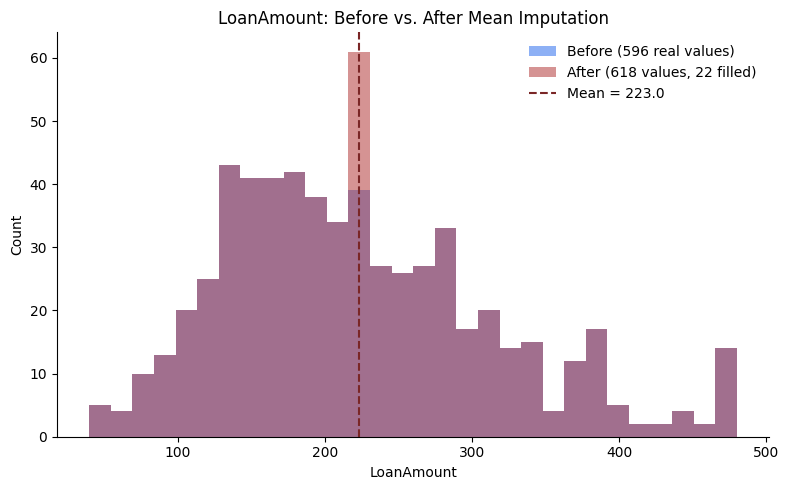

In [12]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(dataset["LoanAmount"].dropna(), bins=30, alpha=0.55, label="Before (596 real values)", color="#2f6fed")
ax.hist(new_dataset["LoanAmount"], bins=30, alpha=0.55, label="After (618 values, 22 filled)", color="#b33a3a")
ax.axvline(dataset["LoanAmount"].mean(), color="#7a2626", linestyle="--", linewidth=1.5,
           label=f'Mean = {dataset["LoanAmount"].mean():.1f}')
ax.set_xlabel("LoanAmount")
ax.set_ylabel("Count")
ax.set_title("LoanAmount: Before vs. After Mean Imputation")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

Look at the bin sitting right on the dashed mean line - the "after" bars pile up noticeably taller there than the "before" bars do, while every other bin mostly overlaps. That's not a coincidence: **all 22 previously-missing values landed in the exact same spot**, creating an artificial spike that never existed in the real, observed data. With only 22 out of 618 values affected (3.6%) it's a small effect here - but the same mechanism becomes a bigger problem the higher the missing percentage climbs.

## Why Not Always Mean? A Cautionary Example

`Credit_History` is a 0/1 flag, not a real continuous number - same lesson as `07_Filling_Missing_Values.MD`. Here's what mean-filling it anyway actually produces, made visible instead of just described.

In [13]:
si_credit = SimpleImputer(strategy="mean")
credit_filled = si_credit.fit_transform(dataset[["Credit_History"]])
credit_series = pd.Series(credit_filled.ravel())
credit_series.value_counts().sort_index()

0.000000     93
0.836268     50
1.000000    475
Name: count, dtype: int64

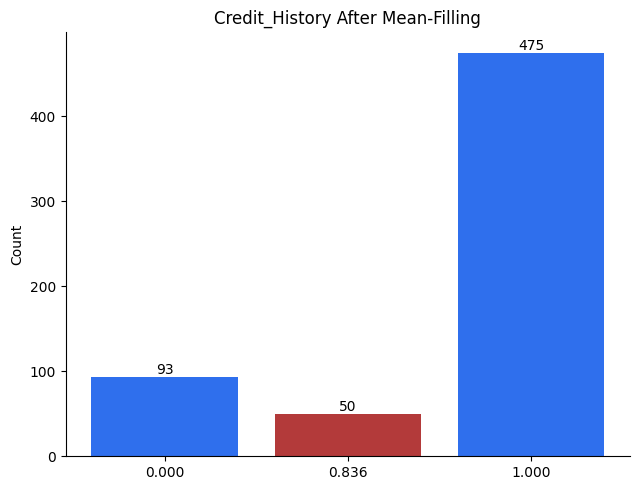

In [14]:
counts = credit_series.value_counts().sort_index()
colors = ["#2f6fed" if round(v, 2) in (0.0, 1.0) else "#b33a3a" for v in counts.index]

plt.figure(figsize=(6.5, 5))
bars = plt.bar([f"{v:.3f}" for v in counts.index], counts.values, color=colors)
plt.bar_label(bars)
plt.title("Credit_History After Mean-Filling")
plt.ylabel("Count")
plt.gca().spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

A third value - `0.836` - shows up **50 times**, exactly matching `Credit_History`'s original missing count. It's not a real credit history status; nobody's credit history is `0.836`. It's the column's mean, standing in for "unknown," and any model reading this column would have no way to tell that fabricated value apart from a genuine measurement.

## All Four SimpleImputer Strategies, Compared

`SimpleImputer` supports four `strategy` values. Applying every one of them to the exact same column - `LoanAmount`'s 22 missing cells - makes the differences concrete instead of abstract.

In [15]:
strategies_to_compare = ["mean", "median", "most_frequent"]
fill_values = {}

for strat in strategies_to_compare:
    si_compare = SimpleImputer(strategy=strat)
    si_compare.fit(dataset[["LoanAmount"]])
    fill_values[strat] = si_compare.statistics_[0]

si_constant = SimpleImputer(strategy="constant", fill_value=150)
si_constant.fit(dataset[["LoanAmount"]])
fill_values["constant (150)"] = 150

fill_values

{'mean': np.float64(223.03187919463087),
 'median': np.float64(208.5),
 'most_frequent': np.float64(480.0),
 'constant (150)': 150}

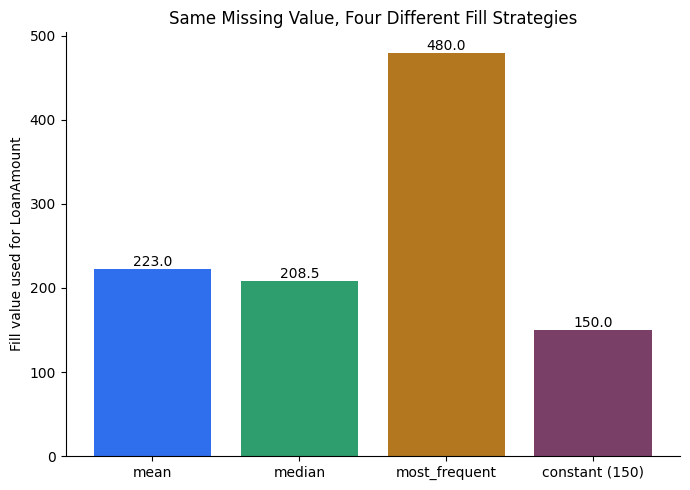

In [16]:
plt.figure(figsize=(7, 5))
colors = ["#2f6fed", "#2f9e6f", "#b3781f", "#7a3f66"]
bars = plt.bar(fill_values.keys(), fill_values.values(), color=colors)
plt.bar_label(bars, fmt="%.1f")
plt.ylabel("Fill value used for LoanAmount")
plt.title("Same Missing Value, Four Different Fill Strategies")
plt.gca().spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

### When to use which

| Strategy | Fills with | Best for | What just happened to `LoanAmount` |
|---|---|---|---|
| `mean` | Average of the column | Numeric, roughly symmetric | `223.0` |
| `median` | Middle value of the column | Numeric, skewed / has outliers | `208.5` - noticeably lower than the mean, a sign `LoanAmount` itself is a bit skewed |
| `most_frequent` | The single most common value | Categorical columns, or a number acting as a flag (like `Credit_History`) | **`480.0`** - the most common *exact* loan amount, which sits near the high end of the range, not anywhere near "typical" |
| `constant` | A fixed value you choose | A clearly-flagged placeholder (e.g. `-1` or `0`) rather than a statistically "reasonable" guess | `150` - whatever `fill_value=` was set to |

`most_frequent`'s result is the tell: for a continuous column like `LoanAmount`, values rarely repeat, so "most common" just means "whichever value happened to tie for the most duplicates" - here that's `480`, a large loan, nowhere near central. `most_frequent` is the right tool for `Gender` / `Married` / `Credit_History`, not for `LoanAmount`.

## Recap

- `SimpleImputer(strategy="mean")` filled `LoanAmount`'s 22 gaps with `223.0` - visibly piling up right at the mean in the before/after chart, a real (if usually minor) side effect of mean imputation worth knowing about.
- Mean-filling a column that's actually a category in disguise (`Credit_History`) invents a value - `0.836` - that never existed in the real data, appearing 50 times where only `0` or `1` should ever appear.
- Four strategies, four different answers for the exact same missing `LoanAmount` cells: `mean` (223.0), `median` (208.5), `most_frequent` (480.0, and clearly the wrong tool here), `constant` (150, whatever you choose).
- Same decision framework as `07_Filling_Missing_Values.MD`, now backed by `scikit-learn` instead of pandas' `.fillna()` - and with the receipts to prove why the choice actually matters, not just in theory.